## ANALISI DEI DATI E PULIZIA DEL DATASET

### Importazione librerie e caricamento del dataset
Importiamo le librerie necessarie e carichiamo il dataset con un controllo e restituendo un errore in caso non venga trovato

In [271]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

file_path = 'datasets/dataset.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Caricamento del dataset avvenuto con successo! Dimensioni: {df.shape}")
else:
    print("ERRORE: Il dataset non è stato trovato.")

Caricamento del dataset avvenuto con successo! Dimensioni: (4424, 35)


### Controlliamo con che tipi di dati andremo a lavorare
Usando df.info() vediamo che la maggior parte dei dati sono di tipo int, per capire a cosa si riferiscono questi dati useremo la leggenda sulla pagina del dataset di **[UCI](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)**

In [272]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

### Controlliamo che non ci siano missing values o duplicati, se ne troviamo li rimuoviamo
Facendo un rapido controllo tramite le funzioni df.isnull() e df.duplicated() notiamo che il dataset non ha missing values o duplicati

In [273]:
#Controllo dei valori nulli
print(f"Valori mancanti per colonna: {df.isnull().sum().sum()}")

#Controllo dei duplicati
print(f"Righe duplicate trovate: {df.duplicated().sum()}")

#Se ci sono duplicati, li rimuoviamo
df = df.drop_duplicates()

Valori mancanti per colonna: 0
Righe duplicate trovate: 0


### Generiamo grafico e percentuali per analizzare la distribuzione degli studenti per quanto riguarda il target
Generando un grafico a torta con le percentuali per analizzare la distribuzione degli studenti per quanto riguarda il target vediamo che i target sono abbastanza bilanciati e potremmo pensare di eliminare il "enrolled" che potrebbe solo confondere le previsioni del nostro modello dovendo predire solo se uno studente abbandonerà (Dropout) o conlcuderà il percorso (Graduate)

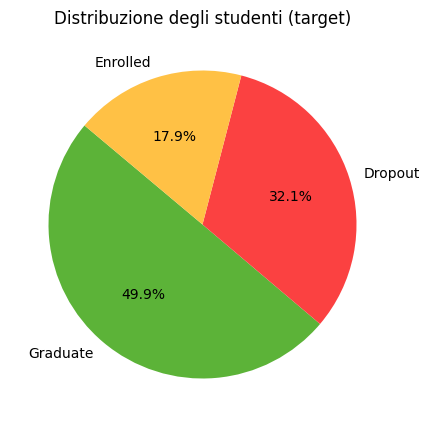

In [274]:
counts = df['Target'].value_counts()
labels = counts.index

plt.figure(figsize=(5,5))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    # colors=('#499d33', '#cc3018', '#cd680e')
    colors=('#5CB338', '#FB4141', '#FFC145')
)

plt.title('Distribuzione degli studenti (target)')
plt.show()

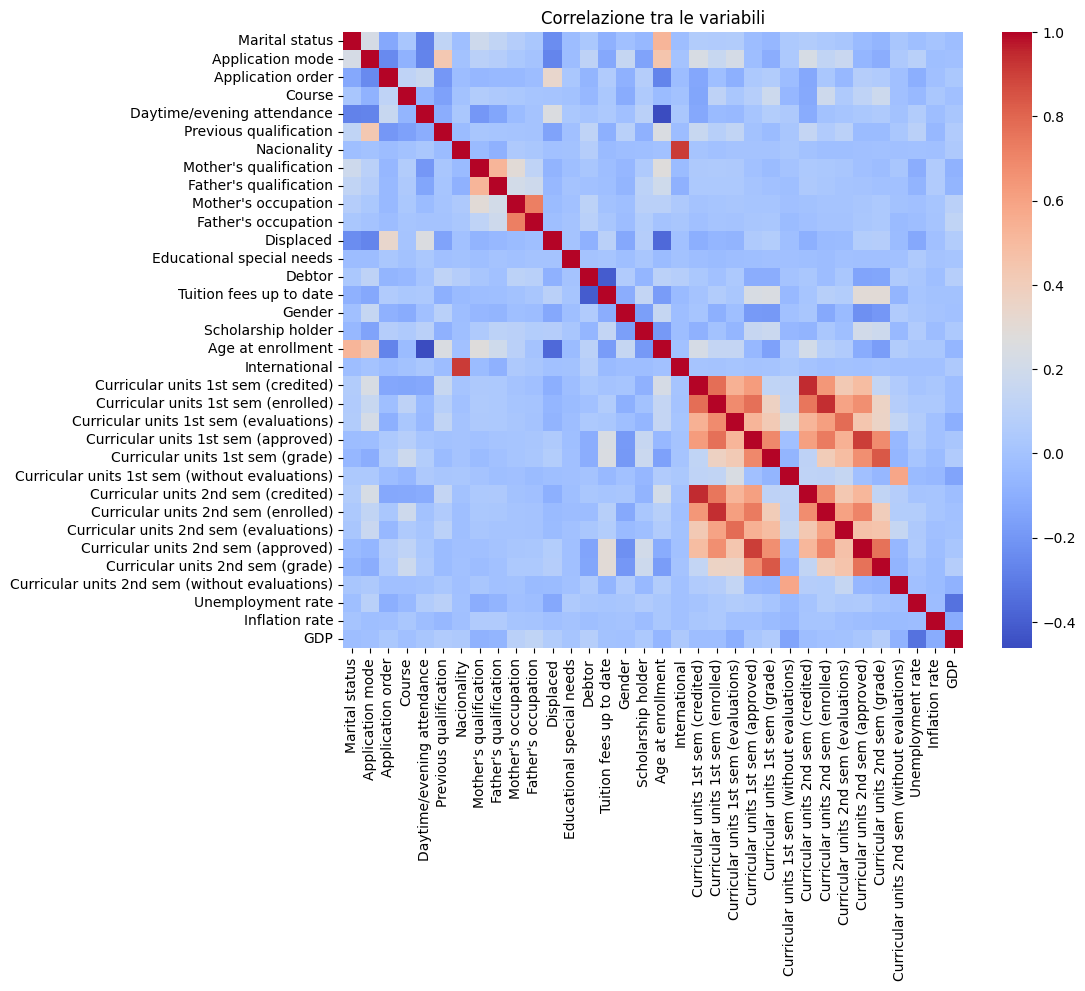

In [275]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlazione tra le variabili')
plt.show()

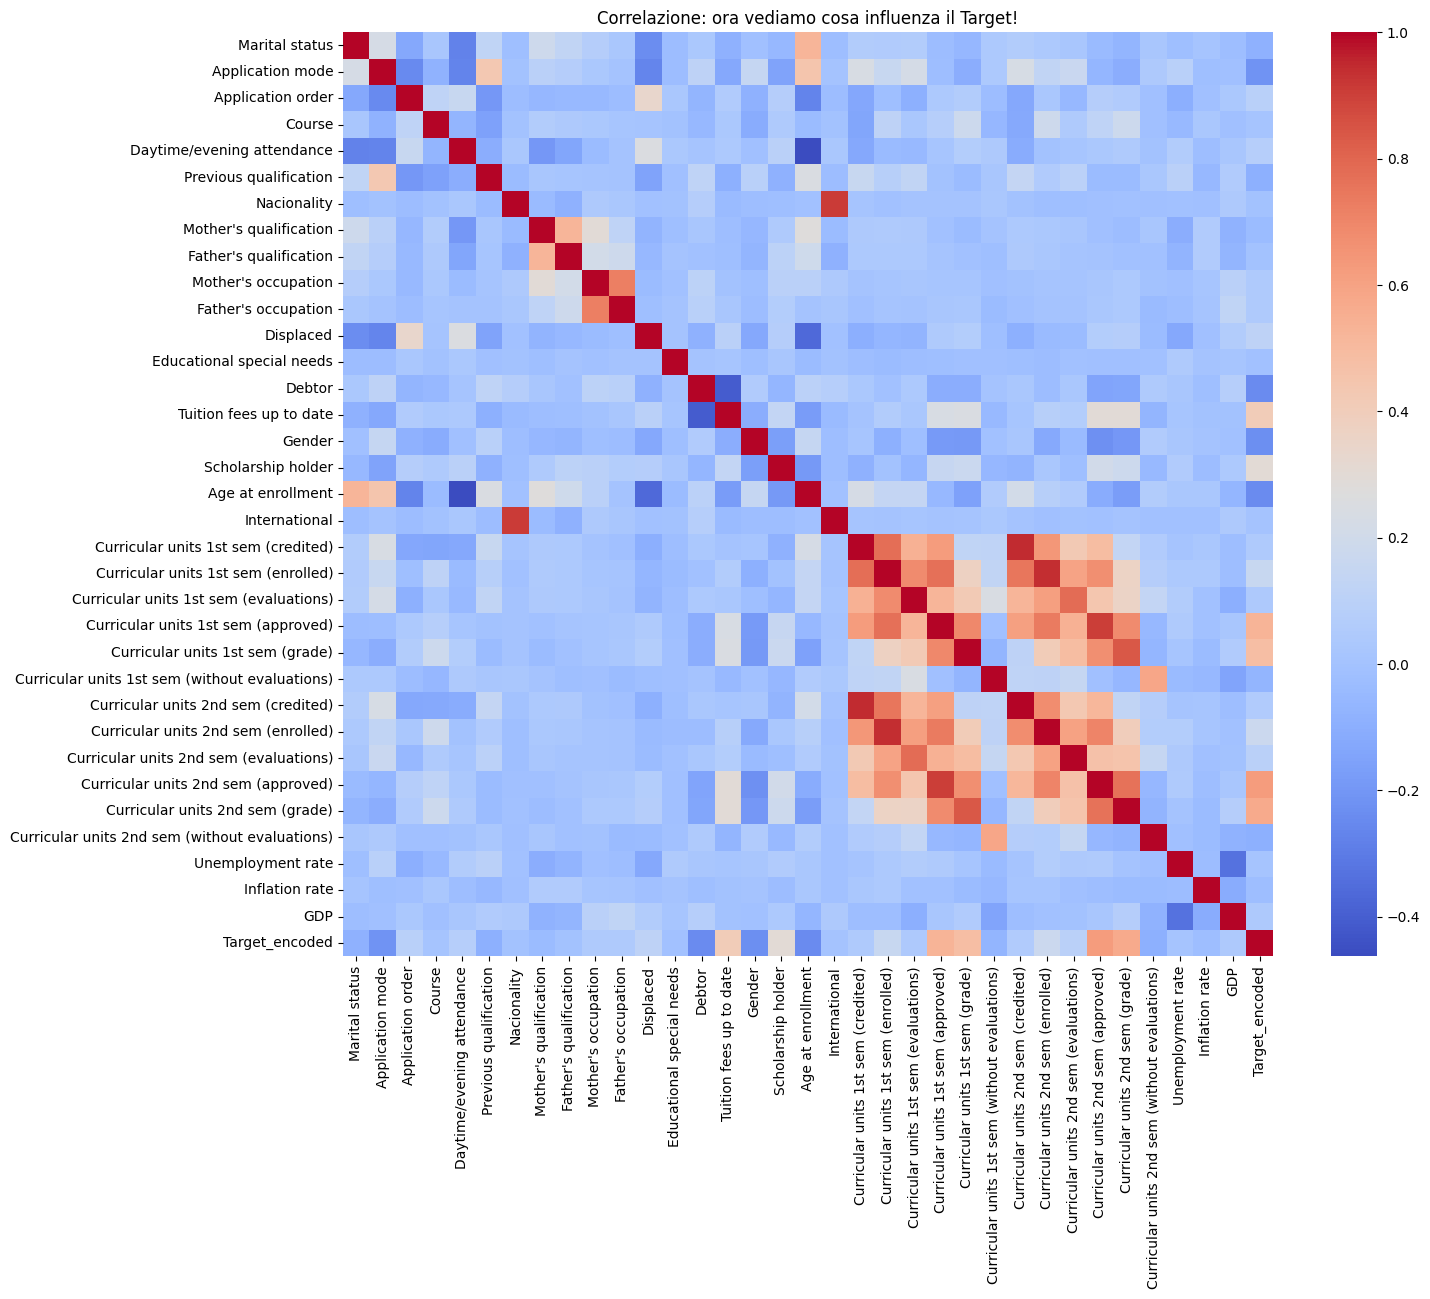

In [ ]:
# Creiamo una copia temporanea e mappiamo il target in numeri
temp_df = df.copy()
temp_df['Target_encoded'] = temp_df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

# Ricalcoliamo la Heatmap includendo il Target_encoded
plt.figure(figsize=(10, 8))
sns.heatmap(temp_df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlazione: ora vediamo cosa influenza il Target!")
plt.show()

#### Generiamo un grafico per controllare gli outlier
Dal grafico vediamo che ci sono diversi outlier (persone con voti >10 nel primo per poi arrivare a 0 nel semestre successivo o viceversa)

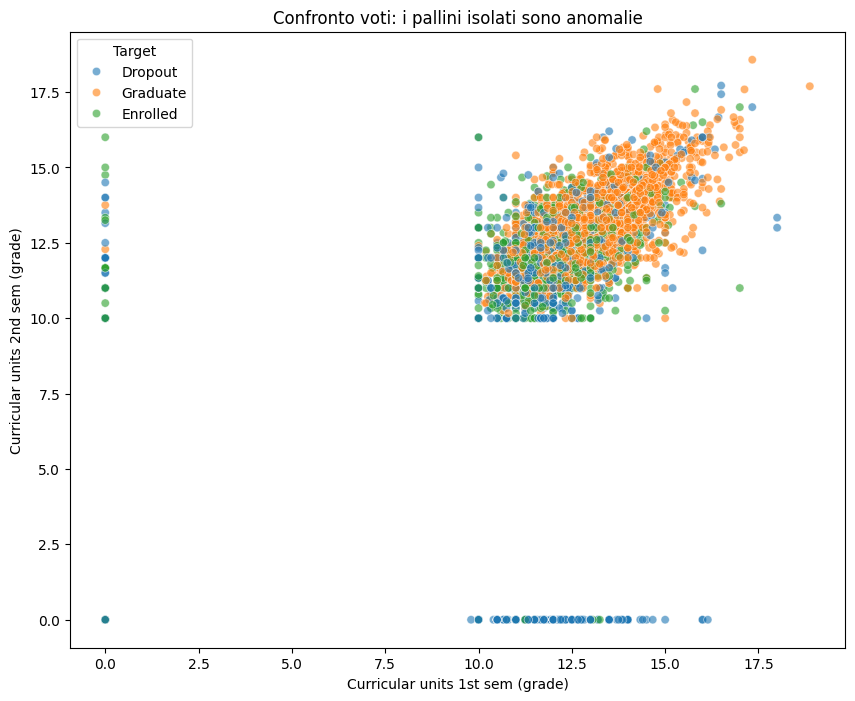

In [278]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Curricular units 1st sem (grade)', 
                y='Curricular units 2nd sem (grade)', 
                hue='Target',
                data=df,
                alpha=0.6)
plt.title("Confronto voti: i pallini isolati sono anomalie")
plt.show()